In [1]:
# What are outliers : An outlier is a value that is much higher or much lower than most of the other values.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data.csv")

In [4]:
df.head()

,employee_id,age,salary,experience_years,monthly_sales
0,1,25,30000,2,200
1,2,28,32000,3,220
2,3,30,35000,5,250
3,4,27,29000,3,210
4,5,29,31000,4,230


In [11]:
df.shape

(30, 5)

In [5]:
# How to check outliers in dataset

In [7]:
# checking if null valuse is present and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   employee_id       30 non-null     int64
 1   age               30 non-null     int64
 2   salary            30 non-null     int64
 3   experience_years  30 non-null     int64
 4   monthly_sales     30 non-null     int64
dtypes: int64(5)
memory usage: 1.3 KB


In [8]:
# checking min/max to check possiblity of outliers
# if found too much difference between mean and max and min possibility of outriers  
df.describe()

,employee_id,age,salary,experience_years,monthly_sales
count,30.000000,30.000000,3.000000e+01,30.000000,30.000000
mean,15.500000,36.666667,1.465000e+05,12.166667,469.166667
std,8.803408,9.671620,3.911057e+05,8.948447,392.665698
min,1.000000,19.000000,1.200000e+04,0.000000,30.000000
25%,8.250000,29.250000,3.525000e+04,4.250000,252.500000
50%,15.500000,36.500000,5.100000e+04,11.500000,390.000000
75%,22.750000,43.750000,6.925000e+04,18.750000,545.000000
max,30.000000,60.000000,2.000000e+06,35.000000,2000.000000


<function matplotlib.pyplot.show(close=None, block=None)>

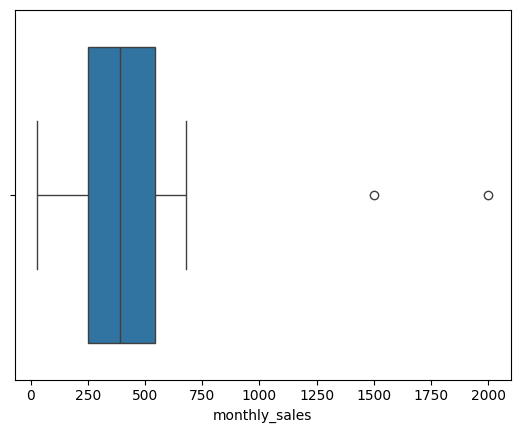

In [10]:
# using boxplot to check outliers 
# checking of monthly sales
sns.boxplot(x = "monthly_sales", data = df)
plt.show()

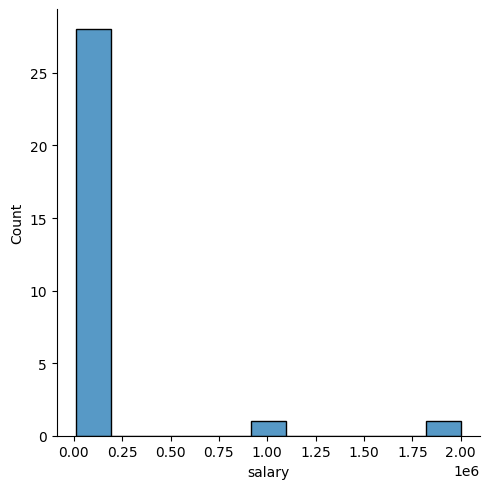

In [13]:
# using distribution to check outliers 
# checking of salary
sns.displot(df["salary"])
plt.show()

In [1]:
# Removing outliers using IQR(Interquartile Range) method

In [9]:
# Step1 find Q1, Q3 and IQR you can also find this using describe fun for reference see above code (for more explaination see the boxplot chart in same folder )
Q1 = df["monthly_sales"].quantile(0.25)
Q3 = df["monthly_sales"].quantile(0.75)
IQR = Q3-Q1
Q1, Q3 , IQR

(np.float64(252.5), np.float64(545.0), np.float64(292.5))

In [10]:
# Step2 find min_range and max_range

min_range = Q1 - (1.5 * IQR)
max_range = Q1 + (1.5 * IQR)
min_range , max_range

(np.float64(-186.25), np.float64(691.25))

In [14]:
# step3 Removing outliers (creating new df which will contain data without outliers)
# here only taking max_range as min_range is in negative othere wise it would be like 
# df1 = df [[df["monthly_sales"] >= min_range] AND [df["monthly_sales"] <= max_range]]

df1 = df[df["monthly_sales"] <= max_range]

In [16]:
df1.shape 
# see outliers are removed now compare shape of df and df1

(28, 5)

In [17]:
# Removing Outliers using Z score

In [1]:
# WE can remove Outilers using Z Score Formula or directly using normal distribution curve plot

In [4]:
# loading dataset in dataframe
dataset = pd.read_csv("data.csv")

In [5]:
# checking null value
dataset.isnull().sum()

employee_id         0
age                 0
salary              0
experience_years    0
monthly_sales       0
dtype: int64

In [21]:
# checking desicription to check outrilers
dataset.describe()
dataset.shape

(30, 5)

<Axes: xlabel='monthly_sales'>

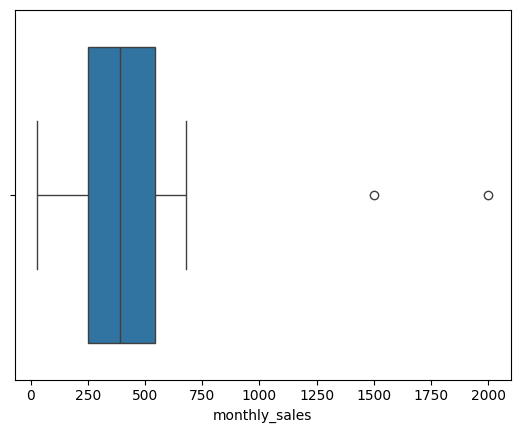

In [8]:
# as outliers are present in monthly sales
# draw boxplot and a distribution plot
sns.boxplot(x = "monthly_sales",data = dataset)

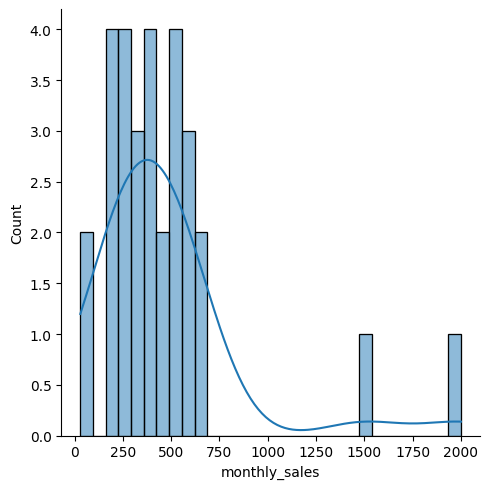

In [13]:
# two outliesrs are present
# let's draw distrubution plot now
# using bins attribute and KDE (Smooth Curve) so tail will be visible as outliers are too streached
sns.displot(dataset["monthly_sales"], bins=30, kde=True)


In [16]:
# now see tail is too streached so outliers is present 
# now we will find min range and max range using Z score (x - u)/d 
# here X = your data, u = mean, d = standard deviation
# In Z score the data present outside this range (u-3d and u + 3d) are outliers

min_range = dataset["monthly_sales"].mean() - (3 * dataset["monthly_sales"].std())
max_range = dataset["monthly_sales"].mean() + (3 * dataset["monthly_sales"].std())

min_range , max_range

(np.float64(-708.8304280548837), np.float64(1647.1637613882172))

In [20]:
# As min_range come in ve- so there is no outliers overthere but only present above max_range

new_data= dataset[dataset["monthly_sales"] <= max_range]
new_data.shape

(29, 5)

In [23]:
# now removing outliers using z score formula (x - u)/d 
# here X = your data, u = mean, d = standard deviation
# First find Z_score

z_score = (dataset["monthly_sales"] - dataset["monthly_sales"].mean()) / (dataset["monthly_sales"].std())
z_score

0    -0.685486
1    -0.634552
2    -0.558151
3    -0.660019
4    -0.609085
5    -0.532684
6    -0.672752
7    -0.507217
8    -0.430816
9    -0.379882
10   -0.328948
11   -0.278014
12   -0.227080
13   -0.176146
14   -0.125213
15   -0.048812
16    0.002122
17    0.053056
18    0.103990
19    0.154924
20    0.205858
21    0.282259
22    0.333193
23    0.384127
24    0.460527
25    0.536928
26    2.625219
27   -1.067490
28    3.898566
29   -1.118424
Name: monthly_sales, dtype: float64

In [24]:
# now adding z_score colunm in are dataset

dataset["z_score"] = z_score
dataset.head()

,employee_id,age,salary,experience_years,monthly_sales,z_score
0,1,25,30000,2,200,-0.685486
1,2,28,32000,3,220,-0.634552
2,3,30,35000,5,250,-0.558151
3,4,27,29000,3,210,-0.660019
4,5,29,31000,4,230,-0.609085


In [27]:
# as we have checked early no negative outlier is present so we will take data which z_score is less that 3

dataset = dataset[dataset["z_score"] < 3]
dataset.shape


(29, 6)

In [ ]:
# Now see one outlier is removed and still one is present but we cannot remove all outliers as ti will lead to 